# Used-Car Price Prediction — EDA & Model Experiments

This notebook explores the cleaned used-car dataset and reproduces the same
comparison of baseline models used in `src/models/train.py`. It is meant as
a readable walkthrough for anyone reviewing the project (e.g. in an
interview), not as the source of truth for the production pipeline — running
`python scripts/train_model.py` is what actually produces `models/*.joblib`.


In [1]:
import sys
sys.path.insert(0, "..")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from src.data.preprocessing import load_and_clean
from src.features.engineering import add_engineered_features

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", None)


## 1. Load and clean the raw dataset

In [2]:
df = load_and_clean(save=False)
print(df.shape)
df.head()


2026-09-05 11:43:36 | INFO     | src.data.preprocessing | Loading raw data from /home/claude/build/car-price-prediction/data/raw/car_dataset.csv


2026-09-05 11:43:36 | INFO     | src.data.preprocessing | Loaded raw data with shape (892, 6)


2026-09-05 11:43:36 | INFO     | src.data.preprocessing | Cleaned data: 892 -> 723 rows (169 removed as invalid/duplicate/outlier)


(723, 6)


,name,company,year,price,kms_driven,fuel_type
0,Hyundai Santro Xing,Hyundai,2007,80000,45000,Petrol
1,Mahindra Jeep CL550,Mahindra,2006,425000,40,Diesel
2,Hyundai Grand i10,Hyundai,2014,325000,28000,Petrol
3,Ford EcoSport Titanium,Ford,2014,575000,36000,Diesel
4,Ford Figo,Ford,2012,175000,41000,Diesel


In [3]:
df.describe(include="all").T


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
name,723,254,Maruti Suzuki Swift,46,NaN,NaN,NaN,NaN,NaN,NaN,NaN
company,723,25,Maruti,202,NaN,NaN,NaN,NaN,NaN,NaN,NaN
year,723.0,NaN,NaN,NaN,2012.319502,4.125321,1995.0,2010.0,2013.0,2015.0,2019.0
price,723.0,NaN,NaN,NaN,392046.228216,374267.285127,30000.0,165000.0,290000.0,489999.0,3100000.0
kms_driven,723.0,NaN,NaN,NaN,46793.820194,34599.288028,0.0,27000.0,42000.0,59000.0,400000.0
fuel_type,723,3,Petrol,390,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## 2. Feature engineering\n\nAdd `car_age` and `kms_per_year`, as used in the production pipeline.

In [4]:
df_fe = add_engineered_features(df)
df_fe[["year", "car_age", "kms_driven", "kms_per_year", "price"]].describe()


,year,car_age,kms_driven,kms_per_year,price
count,723.000000,723.000000,723.000000,723.000000,7.230000e+02
mean,2012.319502,11.680498,46793.820194,4175.784294,3.920462e+05
std,4.125321,4.125321,34599.288028,3394.690827,3.742673e+05
min,1995.000000,5.000000,0.000000,0.000000,3.000000e+04
25%,2010.000000,9.000000,27000.000000,2454.545455,1.650000e+05
50%,2013.000000,11.000000,42000.000000,3461.538462,2.900000e+05
75%,2015.000000,14.000000,59000.000000,4919.871795,4.899990e+05
max,2019.000000,29.000000,400000.000000,28571.428571,3.100000e+06


## 3. Target distribution

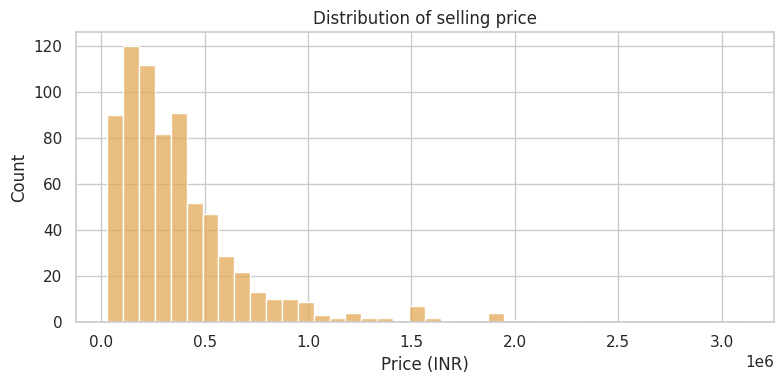

In [5]:
fig, ax = plt.subplots(figsize=(8, 4))
sns.histplot(df_fe["price"], bins=40, ax=ax, color="#E3A857")
ax.set_title("Distribution of selling price")
ax.set_xlabel("Price (INR)")
plt.tight_layout()
plt.show()


The price distribution is right-skewed: most cars sell below ₹5 lakh, with a long tail of premium/luxury cars pulling the mean above the median.

## 4. Price vs car age

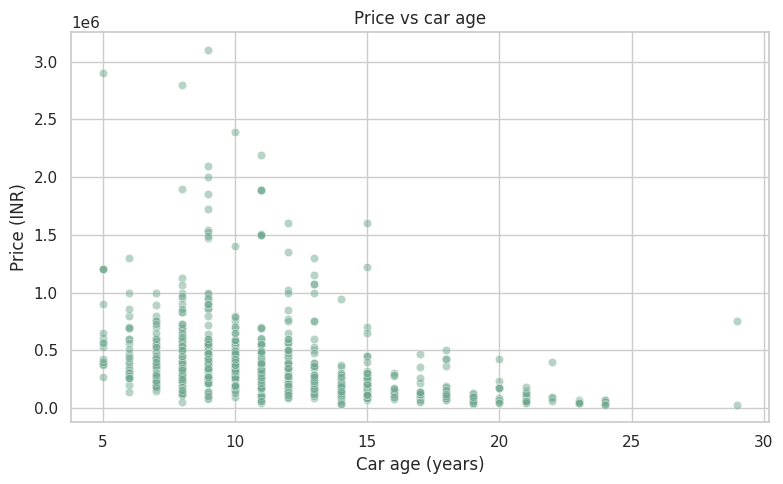

In [6]:
fig, ax = plt.subplots(figsize=(8, 5))
sns.scatterplot(data=df_fe, x="car_age", y="price", alpha=0.5, ax=ax, color="#6FA88F")
ax.set_title("Price vs car age")
ax.set_xlabel("Car age (years)")
ax.set_ylabel("Price (INR)")
plt.tight_layout()
plt.show()


Price falls sharply in the first ~5 years and then flattens out — consistent with typical depreciation curves, where a car loses most of its value early.

## 5. Price vs kilometers driven

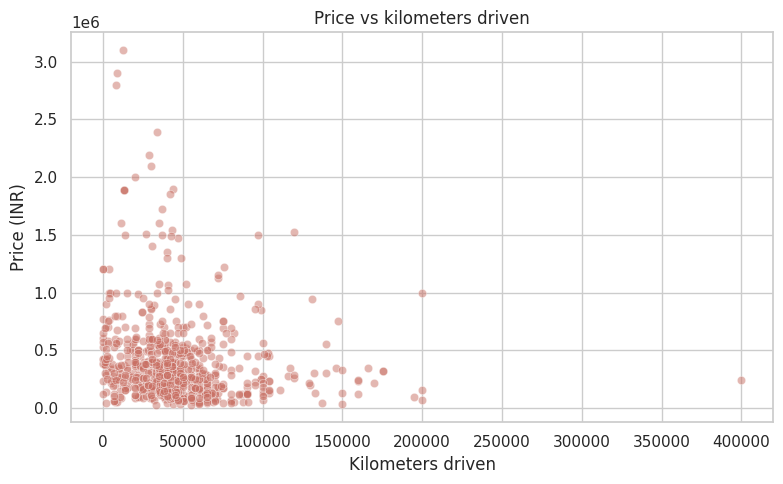

In [7]:
fig, ax = plt.subplots(figsize=(8, 5))
sns.scatterplot(data=df_fe, x="kms_driven", y="price", alpha=0.5, ax=ax, color="#C97064")
ax.set_title("Price vs kilometers driven")
ax.set_xlabel("Kilometers driven")
ax.set_ylabel("Price (INR)")
plt.tight_layout()
plt.show()


## 6. Price by fuel type

/tmp/ipykernel_761/4173383330.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_fe, x="fuel_type", y="price", order=order, ax=ax, palette="crest")


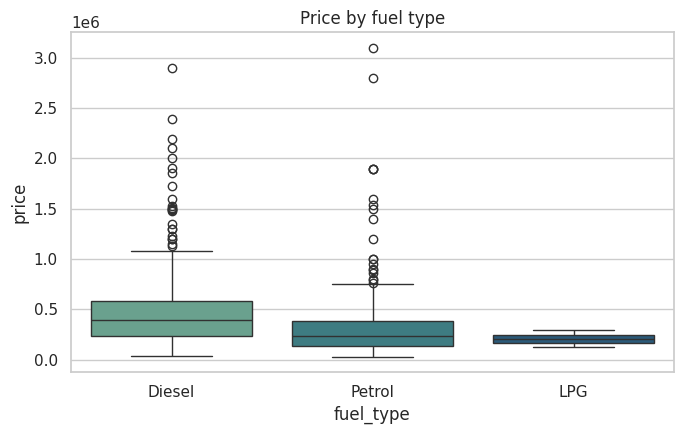

In [8]:
fig, ax = plt.subplots(figsize=(7, 4.5))
order = df_fe.groupby("fuel_type")["price"].median().sort_values(ascending=False).index
sns.boxplot(data=df_fe, x="fuel_type", y="price", order=order, ax=ax, palette="crest")
ax.set_title("Price by fuel type")
plt.tight_layout()
plt.show()


Diesel cars command a higher median resale price than petrol in this dataset, likely because diesel variants are more common among larger/premium models, while LPG conversions (usually older, budget vehicles) sell for less.

## 7. Price by transmission\n\nThe raw dataset scraped for this project does not include a transmission column (only `name`, `company`, `year`, `Price`, `kms_driven`, `fuel_type`), so this cut is not available. This is intentionally left out rather than invented — see the README's Dataset section.

## 8. Top brands by median price

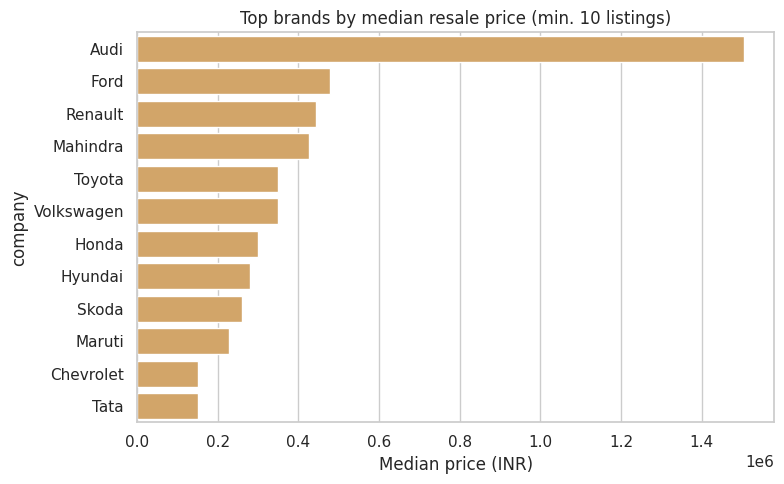

In [9]:
top_brands = (
    df_fe.groupby("company")["price"]
    .agg(["median", "count"])
    .query("count >= 10")
    .sort_values("median", ascending=False)
    .head(12)
)
fig, ax = plt.subplots(figsize=(8, 5))
sns.barplot(x=top_brands["median"], y=top_brands.index, ax=ax, color="#E3A857")
ax.set_xlabel("Median price (INR)")
ax.set_title("Top brands by median resale price (min. 10 listings)")
plt.tight_layout()
plt.show()


## 9. Correlation between numeric features

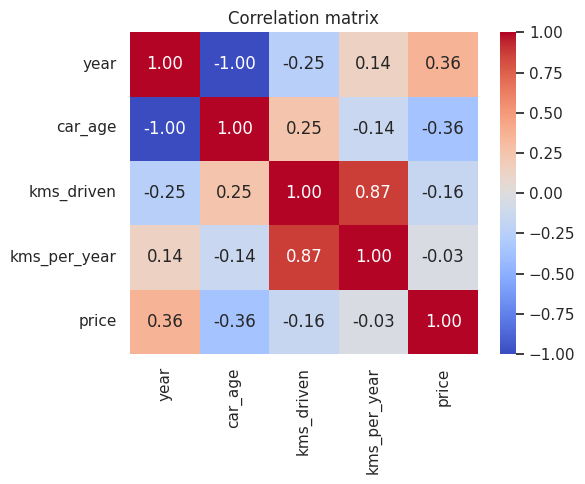

In [10]:
numeric_cols = ["year", "car_age", "kms_driven", "kms_per_year", "price"]
corr = df_fe[numeric_cols].corr()
fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0, ax=ax)
ax.set_title("Correlation matrix")
plt.tight_layout()
plt.show()


`car_age` and `year` are (by construction) almost perfectly anti-correlated, and both correlate more strongly with price than `kms_driven` does — suggesting age is the dominant depreciation driver in this dataset, with mileage playing a secondary role.

## 10. Model comparison\n\nThis reproduces the same comparison run in `src/models/train.py`. For the authoritative, up-to-date numbers see `models/metrics.json`, generated by `python scripts/train_model.py`.

In [11]:
from src.models.train import compare_models
from src.features.engineering import split_features_target
from sklearn.model_selection import train_test_split
from src.utils.config import RANDOM_SEED, TEST_SIZE, TARGET_COLUMN

X, y = split_features_target(df_fe, TARGET_COLUMN)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=TEST_SIZE, random_state=RANDOM_SEED
)
results = compare_models(X_train, y_train)
pd.DataFrame(results).T.sort_values("cv_mae_mean")


2026-09-05 11:43:38 | INFO     | src.models.train | Model=ridge                  CV MAE = 123099 (+/- 14482) [0.1s]


2026-09-05 11:43:41 | INFO     | src.models.train | Model=random_forest          CV MAE = 126524 (+/- 15941) [3.6s]


2026-09-05 11:43:42 | INFO     | src.models.train | Model=gradient_boosting      CV MAE = 139573 (+/- 17250) [0.7s]


2026-09-05 11:43:44 | INFO     | src.models.train | Model=hist_gradient_boosting CV MAE = 194446 (+/- 22999) [2.0s]


,cv_mae_mean,cv_mae_std,seconds
ridge,123099.053814,14482.464938,0.13
random_forest,126524.161816,15940.760809,3.59
gradient_boosting,139572.637581,17250.129327,0.71
hist_gradient_boosting,194445.883860,22998.933163,1.98


## 11. Conclusion\n\nWith only ~700 clean rows and a high-cardinality `name` column (250+ unique listing titles), a regularized linear model (Ridge) generalizes better under cross-validation than the tree ensembles, which tend to overfit the sparse one-hot encoded categories. See the README's *Best Model* section for the final tuned result on the held-out test set.